In [17]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import classA_U1FGTN as mod  # import the module
importlib.reload(mod)        # reload the module
from classA_U1FGTN import classA_U1FGTN  # pull the class after reload


In [18]:
# Cell 2: instantiate the model (DW off, topological mass = 1)
Nx = Ny = 12
model = classA_U1FGTN(
    Nx=Nx,
    Ny=Ny,
    DW=True,        
    nshell=2,
    alpha_1=30,      # mass has non-trans-invariant profile if alpha_1 != alpha_2
    alpha_2=1,      # only alpha_1 matters when DW=False 
)


DWs at x=(3, 8)
------------------------- classA_U1FGTN Initialized -------------------------


In [19]:
# Cell 3: run deterministic Markov channel (no history, no saving)
result = model.run_markov_channel(
    G_history=False,
    progress=True,
    cycles=20,   # choose your total cycles; adjust as needed
    p=1,
    init_mode="default",
    save=False,
    n_a=0.5,
    sequence='random'
)

G_ss = result["G_final"]  # steady-state top-layer covariance
G_ss.shape


Markov channel (sites):   0%|          | 0/2880 [00:00<?, ?site/s]

(288, 288)

In [20]:
# Cell 4: compute local Chern marker on the steady state
C = model.local_chern_marker_flat(G_ss)
C.shape


(12, 12)

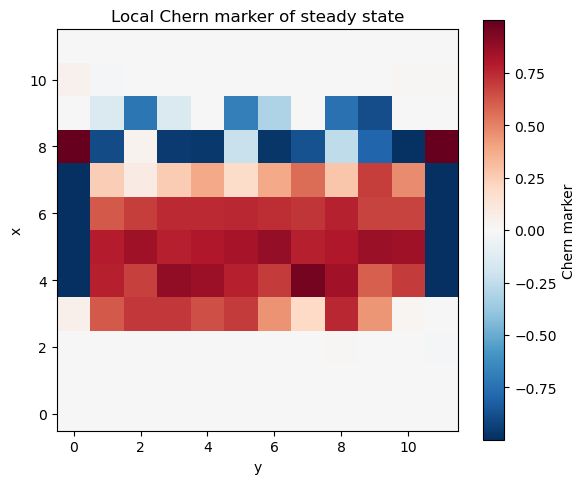

In [21]:
# Cell 5: plot the local Chern marker
plt.figure(figsize=(6, 5))
im = plt.imshow(C, origin="lower", cmap="RdBu_r")
plt.colorbar(im, label="Chern marker")
plt.title("Local Chern marker of steady state")
plt.xlabel("y")
plt.ylabel("x")
plt.tight_layout()
plt.show()


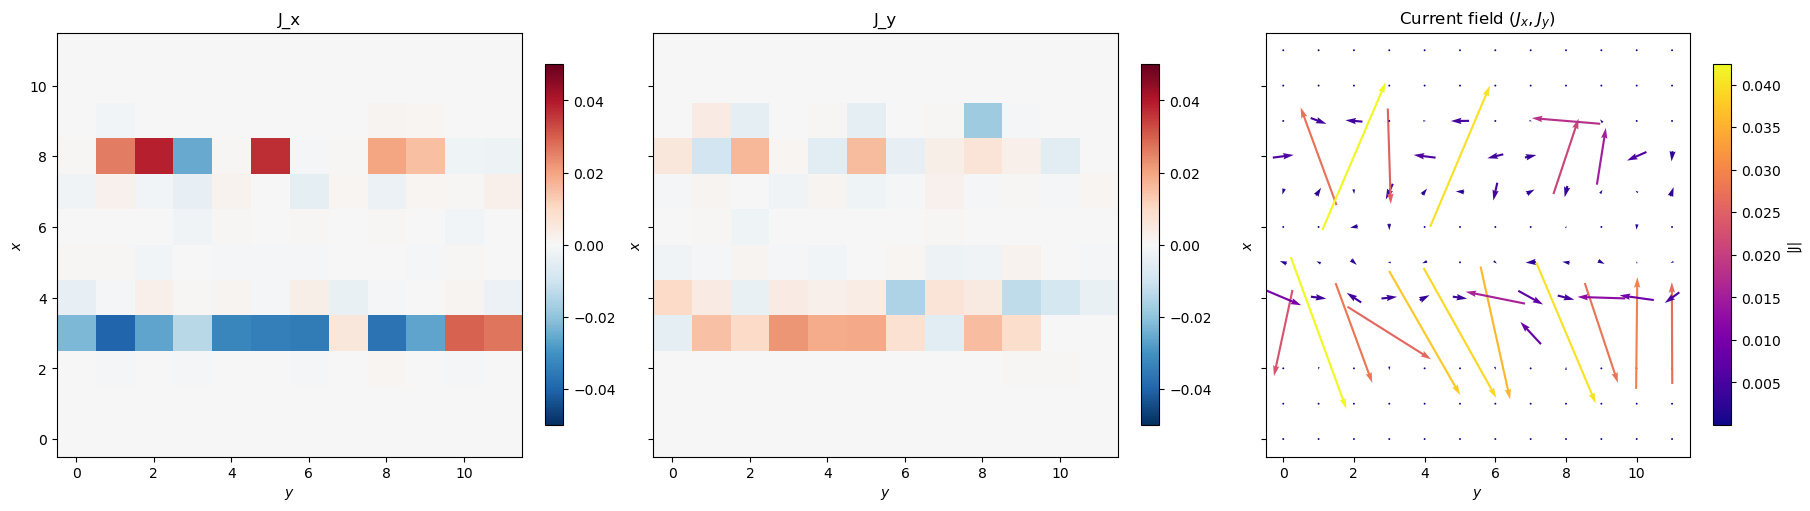

In [22]:
# Compute and plot gauge-invariant current maps from steady state G_ss
J_x, J_y = model.current_maps_gauge_invariant(G_ss)
fig, axes = model.plot_current_maps(J_x, J_y, figsize=(18, 5), sharey=True, vmin=-0.05, vmax=+0.05)
plt.show()


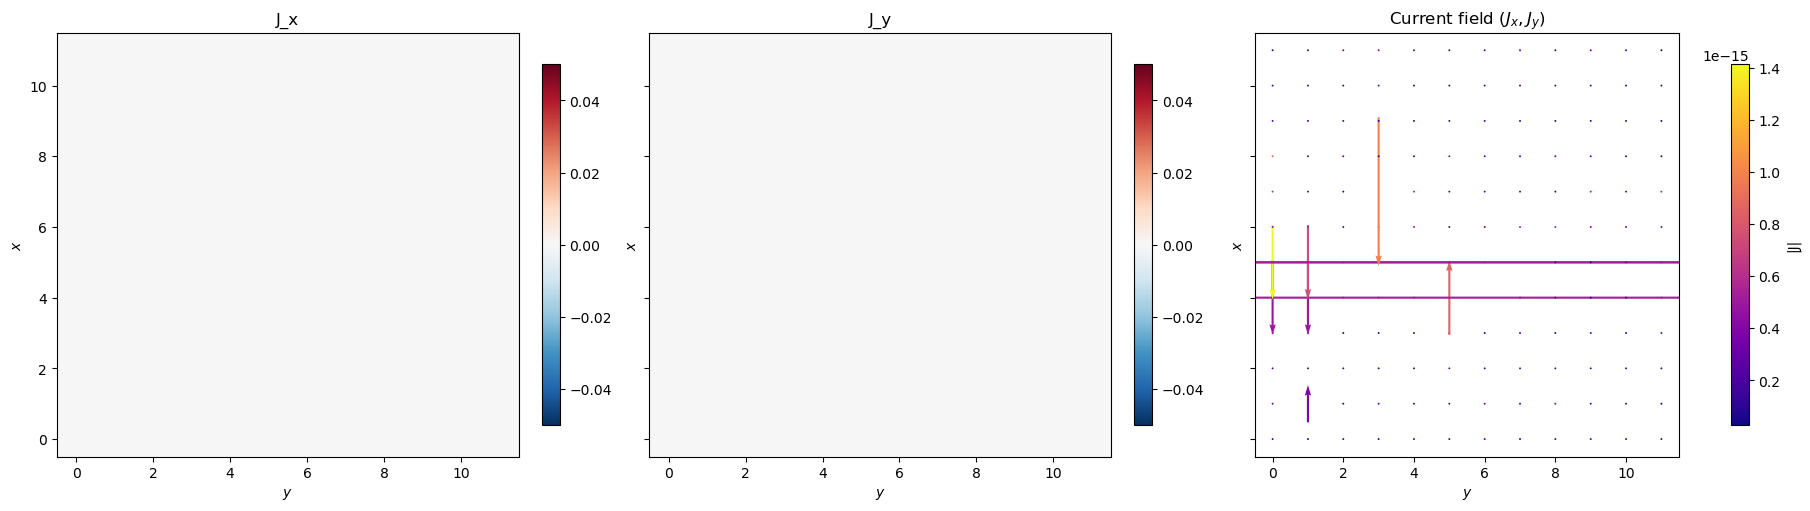

In [16]:
G_CI_DW = model.G_CI_domain_wall()
J_x, J_y = model.current_maps_gauge_invariant(G_CI_DW)
fig, axes = model.plot_current_maps(J_x, J_y, figsize=(18, 5), sharey=True, vmin=-0.05, vmax=+0.05)
plt.show()

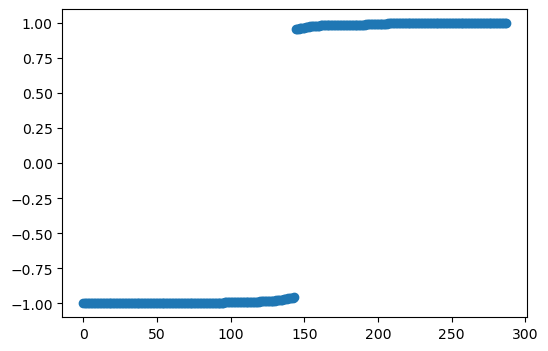

In [14]:
eigvals = np.linalg.eigvalsh(G_ss)
plt.figure(figsize=(6, 4))
plt.plot(eigvals, "o")

In [15]:
# Check y-translation invariance of the steady-state top-layer covariance G_ss
report = model.check_y_translation_invariance(G_ss, tol_shift=1e-10, tol_offdiag=1e-10, hermitize=True)
print(report)


{'shape_ok': True, 'Ny': 12, 'shift_max_abs_diff': 0.02595479631034415, 'shift_pass': False, 'offdiag_ratio': 3.7675106615206065e-05, 'offdiag_pass': False}


DWs at x=(4, 11)
------------------------- classA_U1FGTN Initialized -------------------------


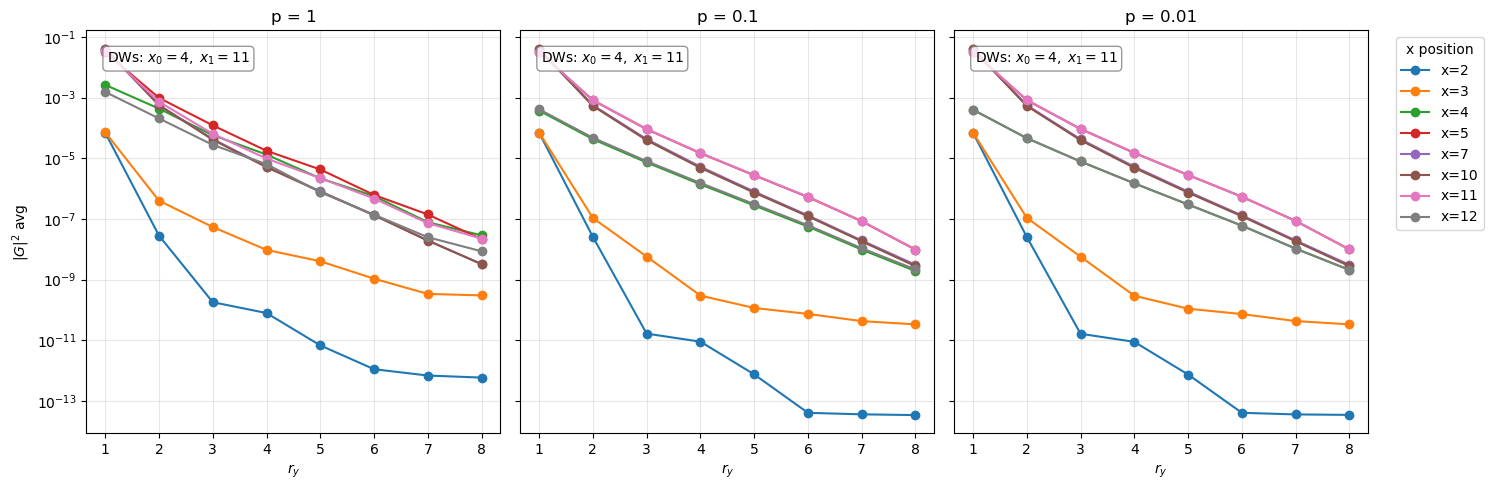

In [ ]:
# random sequence version

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from classA_U1FGTN import classA_U1FGTN

# Match the generation run
P_LIST = [1.0, 1e-1, 1e-2]
CYCLES = 20
Nx = Ny = 16

# Instantiate to reuse DW locations/shapes
model = classA_U1FGTN(Nx=Nx, Ny=Ny, DW=True, nshell=None, alpha_1=30, alpha_2=1)
xL, xR = model.DW_loc

def _pick_x_positions():
    xs = [
        (xL // 2) % Nx,
        (xL - 1) % Nx, xL % Nx, (xL + 1) % Nx,
        ((xL + xR) // 2) % Nx,
        (xR - 1) % Nx, xR % Nx, (xR + 1) % Nx,
        (xR + (Nx // 2)) % Nx,
    ]
    seen, uniq = set(), []
    for x in xs:
        if x not in seen:
            uniq.append(int(x)); seen.add(int(x))
    return [(x, f"{x}") for x in uniq]

def expected_path(p):
    sweeps = int(round(CYCLES / p))
    key = f"N{Nx}x{Ny}_S{sweeps}_nshNone_DW1_init-default_n_a0.5_p{p}_markov_channel_DW1_seq_ran.npz"
    return Path("cache") / "G_history_samples" / key

def corr_y_profile(G_top, x0):
    """Return (ry_vals, profile) for ry=1..Ny//2."""
    Nlayer = 2 * Nx * Ny
    G_top = np.asarray(G_top, dtype=np.complex128)
    if G_top.shape != (Nlayer, Nlayer):
        raise ValueError(f"Expected ({Nlayer},{Nlayer}), got {G_top.shape}")

    G2 = 0.5 * (G_top + np.eye(Nlayer, dtype=np.complex128))
    G6 = G2.reshape(2, Nx, Ny, 2, Nx, Ny, order="F")
    G6 = np.transpose(G6, (1, 2, 0, 4, 5, 3))  # (Nx,Ny,2, Nx,Ny,2)

    ry_vals = np.arange(1, Ny // 2 + 1, dtype=int)  # start at 1
    Ny_loc = Ny
    x0 = int(x0) % Nx

    Gx = G6[x0, :, :, x0, :, :]  # (Ny,2,Ny,2)
    Y = np.arange(Ny_loc, dtype=np.intp)[:, None]
    prof = []
    for ry in ry_vals:
        Yp = (Y + ry) % Ny_loc
        blocks = Gx[Y, :, Yp, :]  # (Ny,2,2)
        prof.append(np.sum(np.abs(blocks) ** 2, axis=(0, 2, 3)) / (2.0 * Ny_loc))
    return ry_vals, np.array(prof, dtype=float)

# Load and collect profiles
profiles = {}  # p -> list of (label, ry, values)
xs = _pick_x_positions()
for p in P_LIST:
    path = expected_path(p)
    if not path.exists():
        print(f"Skipping p={p}: missing {path}")
        continue
    data = np.load(path)
    G_ss = data["G_final"]
    entries = []
    for x, label in xs:
        ry, vals = corr_y_profile(G_ss, x)
        entries.append((label, ry, vals))
    profiles[p] = entries

# Plot: one subplot per p, log-log
fig, axes = plt.subplots(1, len(profiles), figsize=(5 * max(1, len(profiles)), 5), sharey=True)
if len(profiles) == 1:
    axes = [axes]

for ax, p in zip(axes, profiles):
    for label, ry, vals in profiles[p]:
        ax.plot(ry, vals, marker="o", label=f"x={label}")
        ax.set_yscale("log")
        ax.set_xscale("linear")
    ax.set_title(f"p = {p:g}")
    ax.set_xlabel(r"$r_y$")
    ax.grid(True, which="both", alpha=0.3)
    # Add DW textbox
    ax.text(
        0.05, 0.95,
        f"DWs: $x_0={xL},\\;x_1={xR}$",
        transform=ax.transAxes,
        ha="left", va="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray", boxstyle="round,pad=0.3")
    )

axes[0].set_ylabel(r"$|G|^2$ avg")
axes[-1].legend(title="x position", bbox_to_anchor=(1.05, 1.0), loc="upper left")


plt.tight_layout()
plt.show()


DWs at x=(4, 11)
------------------------- classA_U1FGTN Initialized -------------------------
Skipping p=0.01: missing cache/G_history_samples/N16x16_S2000_nshNone_DW1_init-default_n_a0.5_p0.01_markov_channel_DW1_seq_def.npz


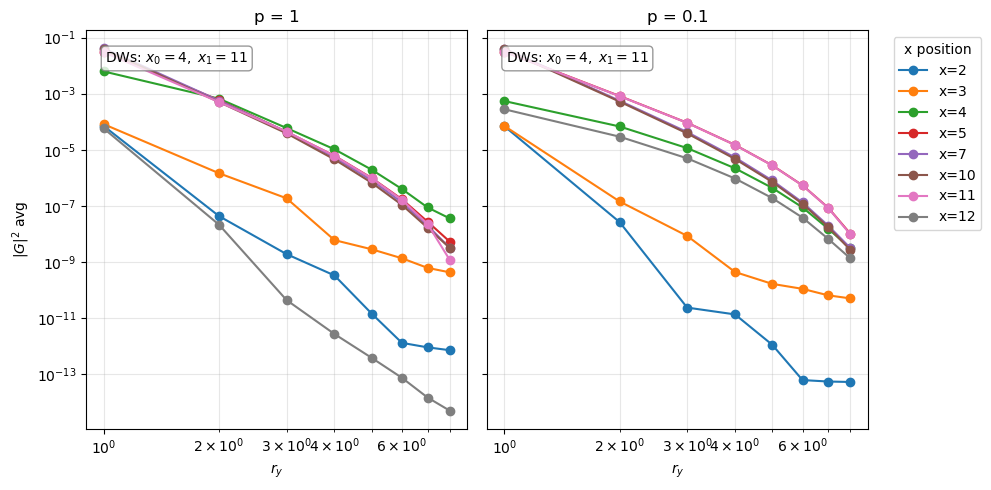

In [23]:
# default sequence version

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from classA_U1FGTN import classA_U1FGTN

# Match the generation run
P_LIST = [1.0, 1e-1, 1e-2]
CYCLES = 20
Nx = Ny = 16

# Instantiate to reuse DW locations/shapes
model = classA_U1FGTN(Nx=Nx, Ny=Ny, DW=True, nshell=None, alpha_1=30, alpha_2=1)
xL, xR = model.DW_loc

def _pick_x_positions():
    xs = [
        (xL // 2) % Nx,
        (xL - 1) % Nx, xL % Nx, (xL + 1) % Nx,
        ((xL + xR) // 2) % Nx,
        (xR - 1) % Nx, xR % Nx, (xR + 1) % Nx,
        (xR + (Nx // 2)) % Nx,
    ]
    seen, uniq = set(), []
    for x in xs:
        if x not in seen:
            uniq.append(int(x)); seen.add(int(x))
    return [(x, f"{x}") for x in uniq]

def expected_path(p):
    sweeps = int(round(CYCLES / p))
    key = f"N{Nx}x{Ny}_S{sweeps}_nshNone_DW1_init-default_n_a0.5_p{p}_markov_channel_DW1_seq_def.npz"
    return Path("cache") / "G_history_samples" / key

def corr_y_profile(G_top, x0):
    """Return (ry_vals, profile) for ry=1..Ny//2."""
    Nlayer = 2 * Nx * Ny
    G_top = np.asarray(G_top, dtype=np.complex128)
    if G_top.shape != (Nlayer, Nlayer):
        raise ValueError(f"Expected ({Nlayer},{Nlayer}), got {G_top.shape}")

    G2 = 0.5 * (G_top + np.eye(Nlayer, dtype=np.complex128))
    G6 = G2.reshape(2, Nx, Ny, 2, Nx, Ny, order="F")
    G6 = np.transpose(G6, (1, 2, 0, 4, 5, 3))  # (Nx,Ny,2, Nx,Ny,2)

    ry_vals = np.arange(1, Ny // 2 + 1, dtype=int)  # start at 1
    Ny_loc = Ny
    x0 = int(x0) % Nx

    Gx = G6[x0, :, :, x0, :, :]  # (Ny,2,Ny,2)
    Y = np.arange(Ny_loc, dtype=np.intp)[:, None]
    prof = []
    for ry in ry_vals:
        Yp = (Y + ry) % Ny_loc
        blocks = Gx[Y, :, Yp, :]  # (Ny,2,2)
        prof.append(np.sum(np.abs(blocks) ** 2, axis=(0, 2, 3)) / (2.0 * Ny_loc))
    return ry_vals, np.array(prof, dtype=float)

# Load and collect profiles
profiles = {}  # p -> list of (label, ry, values)
xs = _pick_x_positions()
for p in P_LIST:
    path = expected_path(p)
    if not path.exists():
        print(f"Skipping p={p}: missing {path}")
        continue
    data = np.load(path)
    G_ss = data["G_final"]
    entries = []
    for x, label in xs:
        ry, vals = corr_y_profile(G_ss, x)
        entries.append((label, ry, vals))
    profiles[p] = entries

# Plot: one subplot per p, log-log
fig, axes = plt.subplots(1, len(profiles), figsize=(5 * max(1, len(profiles)), 5), sharey=True)
if len(profiles) == 1:
    axes = [axes]

for ax, p in zip(axes, profiles):
    for label, ry, vals in profiles[p]:
        ax.plot(ry, vals, marker="o", label=f"x={label}")
        ax.set_yscale("log")
        ax.set_xscale("log")
    ax.set_title(f"p = {p:g}")
    ax.set_xlabel(r"$r_y$")
    ax.grid(True, which="both", alpha=0.3)
    # Add DW textbox
    ax.text(
        0.05, 0.95,
        f"DWs: $x_0={xL},\\;x_1={xR}$",
        transform=ax.transAxes,
        ha="left", va="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray", boxstyle="round,pad=0.3")
    )

axes[0].set_ylabel(r"$|G|^2$ avg")
axes[-1].legend(title="x position", bbox_to_anchor=(1.05, 1.0), loc="upper left")


plt.tight_layout()
plt.show()
